['time_s', 'ax', 'ay', 'az']
Detected sample rate: 499.74 Hz  (dt = 2.00 ms)
Recording duration: 110.48 s, 55215 samples

Analysis window: 2.3s to 99.5s  ->  48578 samples, 97.20s duration
Estimated gravity/DC offset removed: 9.7862 m/s^2 (nominal g = 9.81)
-0.0006096883589946038


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

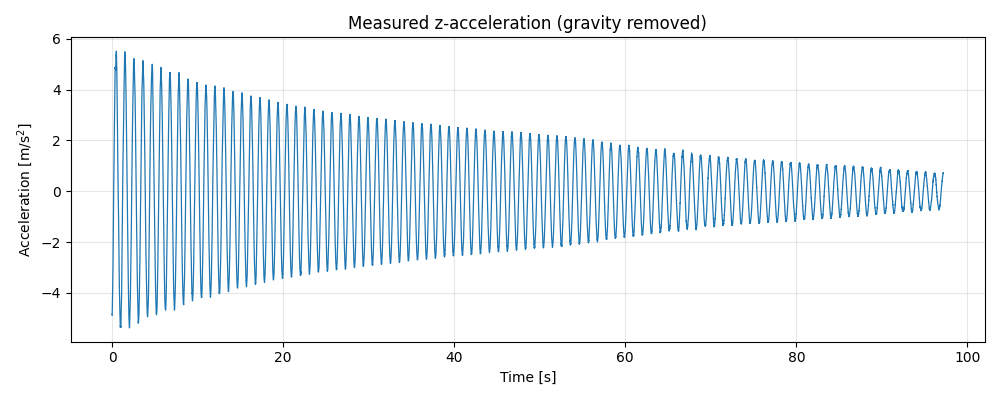

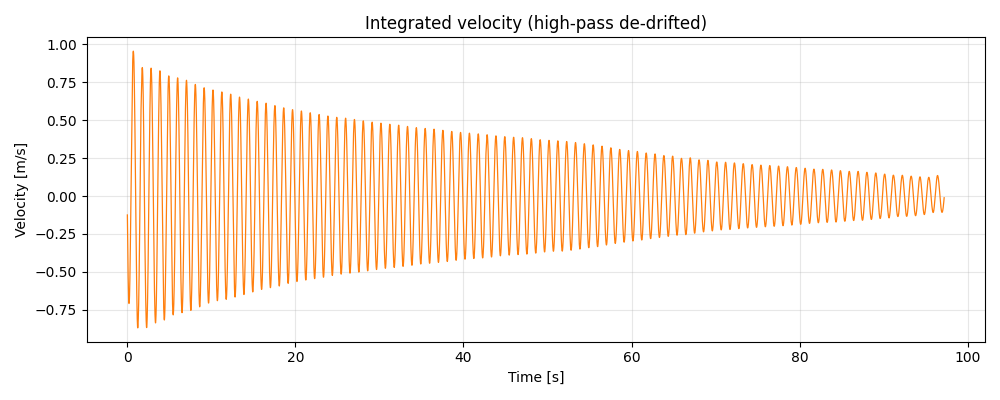

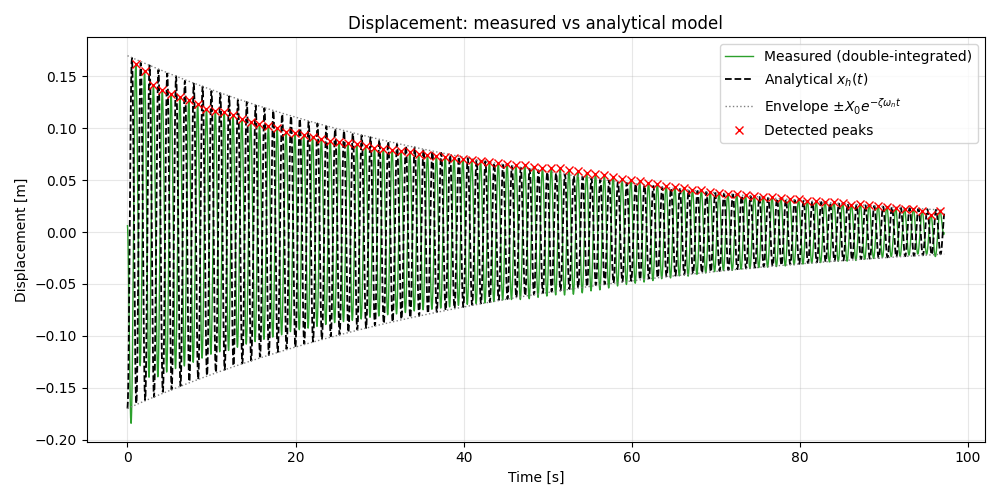

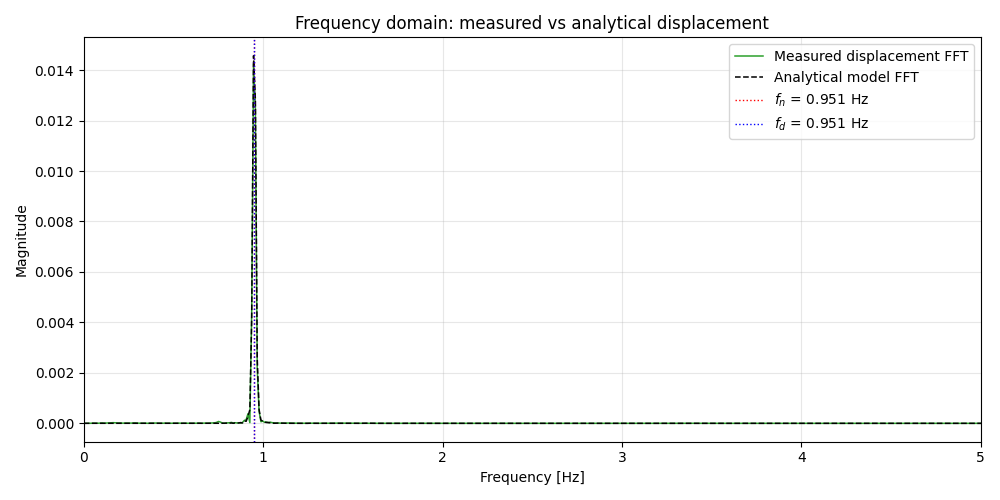

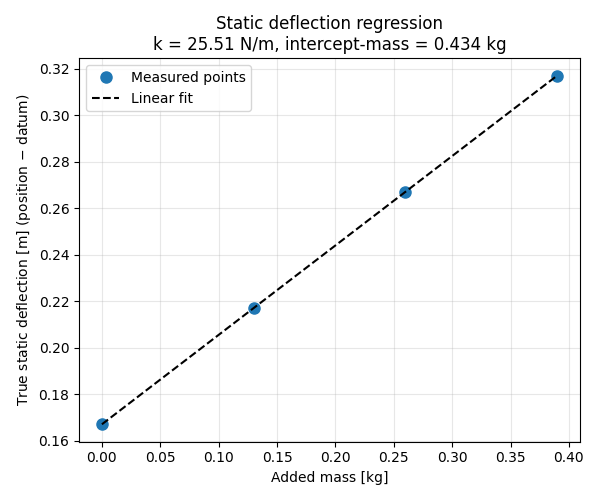


================= SUMMARY =================
Spring stiffness k (from regression slope)     = 25.506 N/m
Phone mass (given/measured)                     = 0.2030 kg
Total oscillating mass, m_total = k/wn^2         = 0.7148 kg
CRADLE MASS, RECOMMENDED = m_total - m_phone     = 0.5118 kg
Cradle mass, from regression intercept (x-check) = 0.4342 kg
Undamped natural frequency  fn = 0.9507 Hz  (wn = 5.9736 rad/s)
Damped natural frequency    fd = 0.9507 Hz  (wd = 5.9735 rad/s)
Damping ratio               zeta = 0.00359


In [1]:
"""
MVR 320 - Practical 1: SDOF free-vibration analysis

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy import signal as sig
from IPython.display import display, Math, Latex
%matplotlib widget
plt.close('all')

# =====================================================================
# ----------------------------- SETTINGS -----------------------------
# =====================================================================

CSV_PATH = r'data 3 spring.csv'

# Initial conditions (as given: pulled down 5 cm, released from rest)
X0 = -0.17   # m, initial displacement magnitude
V0 = 0.0          # m/s, initial velocity (released from rest)

M_PHONE = 0.203    # kg -- EDIT THIS to your phone's actual mass


SHOW_FULL_SIGNAL = False


T_START = 2.3  # s -- start just after release transient settles
T_END   = 99.5   # s -- end while oscillation is still clearly visible above noise

DATUM = 0.263     # m

# STATIC_ADDED_MASS = np.array([0.0, 0.13, 0.26, 0.39])       # kg
# STATIC_POSITION   = np.array([0.405, 0.458, 0.512, 0.568])  # m, absolute position from datum reference
STATIC_ADDED_MASS = np.array([0.0, 0.13, 0.26, 0.39])   # kg
STATIC_POSITION = np.array([0.43, 0.48, 0.53, 0.58])  # m
g = 9.81  # m/s^2

# =====================================================================
# ------------------------- LOAD & PREP DATA --------------------------
# =====================================================================

df = pd.read_csv(CSV_PATH)
print(df.columns.tolist())
t_full = df["time_s"].values
az_full = df["az"].values  # includes +g offset (phone flat, z pointing up)

fs = 1.0 / np.mean(np.diff(t_full))
print(f"Detected sample rate: {fs:.2f} Hz  (dt = {1/fs*1000:.2f} ms)")
print(f"Recording duration: {t_full[-1]:.2f} s, {len(t_full)} samples")

if SHOW_FULL_SIGNAL:
    plt.figure(figsize=(10, 4))
    plt.plot(t_full, az_full, lw=0.8)
    plt.xlabel("Time [s]")
    plt.ylabel("az [m/s^2] (incl. gravity)")
    plt.title("FULL raw z-acceleration signal - pick T_START/T_END from this")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("\nInspect the plot, choose T_START and T_END (clean decaying-oscillation region),")
    print("set SHOW_FULL_SIGNAL = False, fill in T_START/T_END, and re-run.")
    raise SystemExit

# ---- Crop to selected window ----
mask = (t_full >= T_START) & (t_full <= T_END)
t = t_full[mask] - t_full[mask][0]   # reset time to start at 0
az = az_full[mask]

n = len(t)
dt = 1.0 / fs
print(f"\nAnalysis window: {T_START}s to {T_END}s  ->  {n} samples, {t[-1]:.2f}s duration")


az_offset = np.mean(az)
a = az - az_offset   # pure dynamic acceleration, m/s^2, gravity removed

print(f"Estimated gravity/DC offset removed: {az_offset:.4f} m/s^2 "
      f"(nominal g = {g})")



def cumtrapz(y, dx):
    """Cumulative trapezoidal integration, returns same length as y, starts at 0."""
    out = np.zeros_like(y)
    out[1:] = np.cumsum((y[1:] + y[:-1]) / 2.0 * dx)
    return out

v_raw = cumtrapz(a, dt)
v_raw += V0 - v_raw[0]   # enforce initial velocity condition
x_raw = cumtrapz(v_raw, dt)

STATIC_DEFLECTION = STATIC_POSITION - DATUM   # true deflection from unloaded spring end

A_mat = np.vstack([STATIC_ADDED_MASS, np.ones_like(STATIC_ADDED_MASS)]).T
slope, intercept = np.linalg.lstsq(A_mat, STATIC_DEFLECTION, rcond=None)[0]
k_static = g / slope
m_cradle_intercept = intercept * k_static / g   # cradle mass from intercept (less reliable, see note)

wn_guess = np.sqrt(k_static / (m_cradle_intercept + M_PHONE))
f_guess = wn_guess / (2 * np.pi)

hp_cutoff = max(0.15, f_guess * 0.3)  # Hz, well below oscillation freq but above drift
sos = sig.butter(2, hp_cutoff, btype="highpass", fs=fs, output="sos")
v = sig.sosfiltfilt(sos, v_raw)
x = sig.sosfiltfilt(sos, x_raw)

peak_idx, _ = find_peaks(x, distance=int(0.3 * fs))
peak_t = t[peak_idx]
peak_x = x[peak_idx]

if len(peak_idx) < 2:
    raise RuntimeError("Fewer than 2 peaks found -- widen T_START/T_END window "
                        "or check signal quality.")

periods = np.diff(peak_t)
Td = np.mean(periods)
wd = 2 * np.pi / Td
f_d = 1 / Td

m_cycles = len(peak_idx) - 1
x1 = peak_x[0]
xm1 = peak_x[-1]
delta = (1 / m_cycles) * np.log(x1 / xm1)
zeta = delta / np.sqrt((2 * np.pi) ** 2 + delta ** 2)
wn = wd / np.sqrt(1 - zeta ** 2)
fn = wn / (2 * np.pi)


m_total_dynamic = k_static / wn ** 2


m_cradle_dynamic = m_total_dynamic - M_PHONE

C1 = X0
C2 = (V0 + zeta * wn * X0) / wd
print(C2)

t_model = np.linspace(0, t[-1], 2000)
# x_model = np.exp(-zeta * wn * t_model) * (C1 * np.cos(wd * t_model) + C2 * np.sin(wd * t_model))
x_model = np.exp(-zeta * wn * t_model) * (C1 * np.cos(wd * t_model) + C2 *  np.sin(wd * t_model))
env = X0 * np.exp(-zeta * wn * t_model)


display(Math(r"\textbf{Step 1: Spring stiffness } k \textbf{ from static deflection}"))

display(Math(
    r"\text{True deflection } \delta_i = x_{\text{position},i} - x_{\text{datum}}"
))
defl_rows = ", \\; ".join(
    f"\\delta_{i+1}={STATIC_POSITION[i]:.3f}-{DATUM:.3f}={STATIC_DEFLECTION[i]:.3f}\\,\\text{{m}}"
    for i in range(len(STATIC_POSITION))
)
display(Math(defl_rows))

display(Math(
    r"\delta_{st} = \frac{g}{k}\,m_{added} + \frac{m_{cradle}\,g}{k} "
    r"\quad\text{(linear regression: slope}=g/k\text{, intercept}=m_{cradle}g/k\text{)}"
))
display(Math(
    rf"\text{{slope}} = {slope:.4f}\,\text{{m/kg}}, \quad "
    rf"\text{{intercept}} = {intercept:.4f}\,\text{{m}}"
))
display(Math(
    rf"k = \frac{{g}}{{\text{{slope}}}} = \frac{{{g}}}{{{slope:.4f}}} "
    rf"= {k_static:.3f}\ \text{{N/m}}"
))

display(Math(r"\textbf{Step 2: Total oscillating mass } m_{total} \textbf{ from } \omega_n"))

display(Math(
    rf"\text{{Log decrement: }}\delta = \frac{{1}}{{m}}\ln\frac{{x_1}}{{x_{{m+1}}}}"
    rf" = \frac{{1}}{{{m_cycles}}}\ln\frac{{{x1:.4f}}}{{{xm1:.4f}}} = {delta:.4f}"
))
display(Math(
    rf"\zeta = \frac{{\delta}}{{\sqrt{{(2\pi)^2+\delta^2}}}} "
    rf"= \frac{{{delta:.4f}}}{{\sqrt{{(2\pi)^2+{delta:.4f}^2}}}} = {zeta:.5f}"
))
display(Math(
    rf"\omega_d = \frac{{2\pi}}{{T_d}} = \frac{{2\pi}}{{{Td:.4f}}} = {wd:.4f}\ \text{{rad/s}}"
    rf"\qquad (f_d = {f_d:.4f}\ \text{{Hz}})"
))
display(Math(
    rf"\omega_n = \frac{{\omega_d}}{{\sqrt{{1-\zeta^2}}}} "
    rf"= \frac{{{wd:.4f}}}{{\sqrt{{1-{zeta:.5f}^2}}}} = {wn:.4f}\ \text{{rad/s}}"
    rf"\qquad (f_n = {fn:.4f}\ \text{{Hz}})"
))
display(Math(
    rf"\omega_n^2 = \frac{{k}}{{m_{{total}}}} \;\;\Rightarrow\;\; "
    rf"m_{{total}} = \frac{{k}}{{\omega_n^2}} "
    rf"= \frac{{{k_static:.3f}}}{{{wn:.4f}^2}} = {m_total_dynamic:.4f}\ \text{{kg}}"
))

display(Math(r"\textbf{Step 3: Cradle mass (subtract phone mass)}"))
display(Math(
    rf"m_{{cradle}} = m_{{total}} - m_{{phone}} "
    rf"= {m_total_dynamic:.4f} - {M_PHONE:.4f} = {m_cradle_dynamic:.4f}\ \text{{kg}}"
))

display(Math(r"\textbf{Cross-check: cradle mass from the regression intercept (less reliable)}"))
display(Math(
    rf"m_{{cradle,\,intercept}} = \frac{{\text{{intercept}}\cdot k}}{{g}} "
    rf"= \frac{{{intercept:.4f}\times {k_static:.3f}}}{{{g}}} = {m_cradle_intercept:.4f}\ \text{{kg}}"
))
display(Math(
    rf"\text{{Discrepancy (dynamic}} - \text{{intercept)}} = "
    rf"{m_cradle_dynamic:.4f} - {m_cradle_intercept:.4f} = "
    rf"{m_cradle_dynamic - m_cradle_intercept:+.4f}\ \text{{kg}}"
))

plt.figure(figsize=(10, 4))
plt.plot(t, a, lw=0.9)
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s$^2$]")
plt.title("Measured z-acceleration (gravity removed)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 2. Velocity vs time ---
plt.figure(figsize=(10, 4))
plt.plot(t, v, lw=0.9, color="tab:orange")
plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Integrated velocity (high-pass de-drifted)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. Displacement vs time: measured vs analytical ---
plt.figure(figsize=(10, 5))
plt.plot(t, x, lw=1.0, color="tab:green", label="Measured (double-integrated)")
plt.plot(t_model, x_model, "--", lw=1.3, color="k", label="Analytical $x_h(t)$")
plt.plot(t_model, env, ":", lw=1.0, color="gray", label=r"Envelope $\pm X_0 e^{-\zeta \omega_n t}$")
plt.plot(t_model, -env, ":", lw=1.0, color="gray")
plt.plot(peak_t, peak_x, "rx", ms=6, label="Detected peaks")
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Displacement: measured vs analytical model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 4. Frequency domain: FFT of measured displacement ---
N = len(x)
X_fft = np.fft.rfft(x * np.hanning(N))
freqs = np.fft.rfftfreq(N, d=dt)
mag = np.abs(X_fft) / N

x_model_sampled = np.exp(-zeta * wn * t) * (C1 * np.cos(wd * t) + C2 * np.sin(wd * t))
Xm_fft = np.fft.rfft(x_model_sampled * np.hanning(N))
mag_model = np.abs(Xm_fft) / N

plt.figure(figsize=(10, 5))
plt.plot(freqs, mag, lw=1.1, color="tab:green", label="Measured displacement FFT")
plt.plot(freqs, mag_model, "--", lw=1.1, color="k", label="Analytical model FFT")
plt.axvline(fn, color="red", ls=":", lw=1, label=f"$f_n$ = {fn:.3f} Hz")
plt.axvline(f_d, color="blue", ls=":", lw=1, label=f"$f_d$ = {f_d:.3f} Hz")
plt.xlim(0, min(5, fs / 2))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Frequency domain: measured vs analytical displacement")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 5. Static deflection regression plot ---
plt.figure(figsize=(6, 5))
plt.plot(STATIC_ADDED_MASS, STATIC_DEFLECTION, "o", ms=8, label="Measured points")
mm = np.linspace(0, STATIC_ADDED_MASS[-1], 50)
plt.plot(mm, slope * mm + intercept, "--", color="k", label="Linear fit")
plt.xlabel("Added mass [kg]")
plt.ylabel("True static deflection [m] (position $-$ datum)")
plt.title(f"Static deflection regression\nk = {k_static:.2f} N/m, "
          f"intercept-mass = {m_cradle_intercept:.3f} kg")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n================= SUMMARY =================")
print(f"Spring stiffness k (from regression slope)     = {k_static:.3f} N/m")
print(f"Phone mass (given/measured)                     = {M_PHONE:.4f} kg")
print(f"Total oscillating mass, m_total = k/wn^2         = {m_total_dynamic:.4f} kg")
print(f"CRADLE MASS, RECOMMENDED = m_total - m_phone     = {m_cradle_dynamic:.4f} kg")
print(f"Cradle mass, from regression intercept (x-check) = {m_cradle_intercept:.4f} kg")
print(f"Undamped natural frequency  fn = {fn:.4f} Hz  (wn = {wn:.4f} rad/s)")
print(f"Damped natural frequency    fd = {f_d:.4f} Hz  (wd = {wd:.4f} rad/s)")
print(f"Damping ratio               zeta = {zeta:.5f}")
print("=============================================")



m = 10.6 kg
k = 50635.02 N/m
zeta = 0.0
x0 = 0.02 m
xdot_0 = 0.73 m/s
Signal     fs (Hz)   Nyquist  Duration(s)  Delta_f (Hz)   Peak (Hz)
Sig1         11.00      5.50        10.91       0.09167      0.0000
Sig2         14.30      7.15        10.91       0.09167      3.2790
Sig3         36.30     18.15        10.96       0.09121     11.0083
Sig4         55.00     27.50        10.98       0.09106     11.0000
Sig5        550.00    275.00       110.00       0.00909     11.0000

True natural frequency (from m, k): fn = 11.0000 Hz


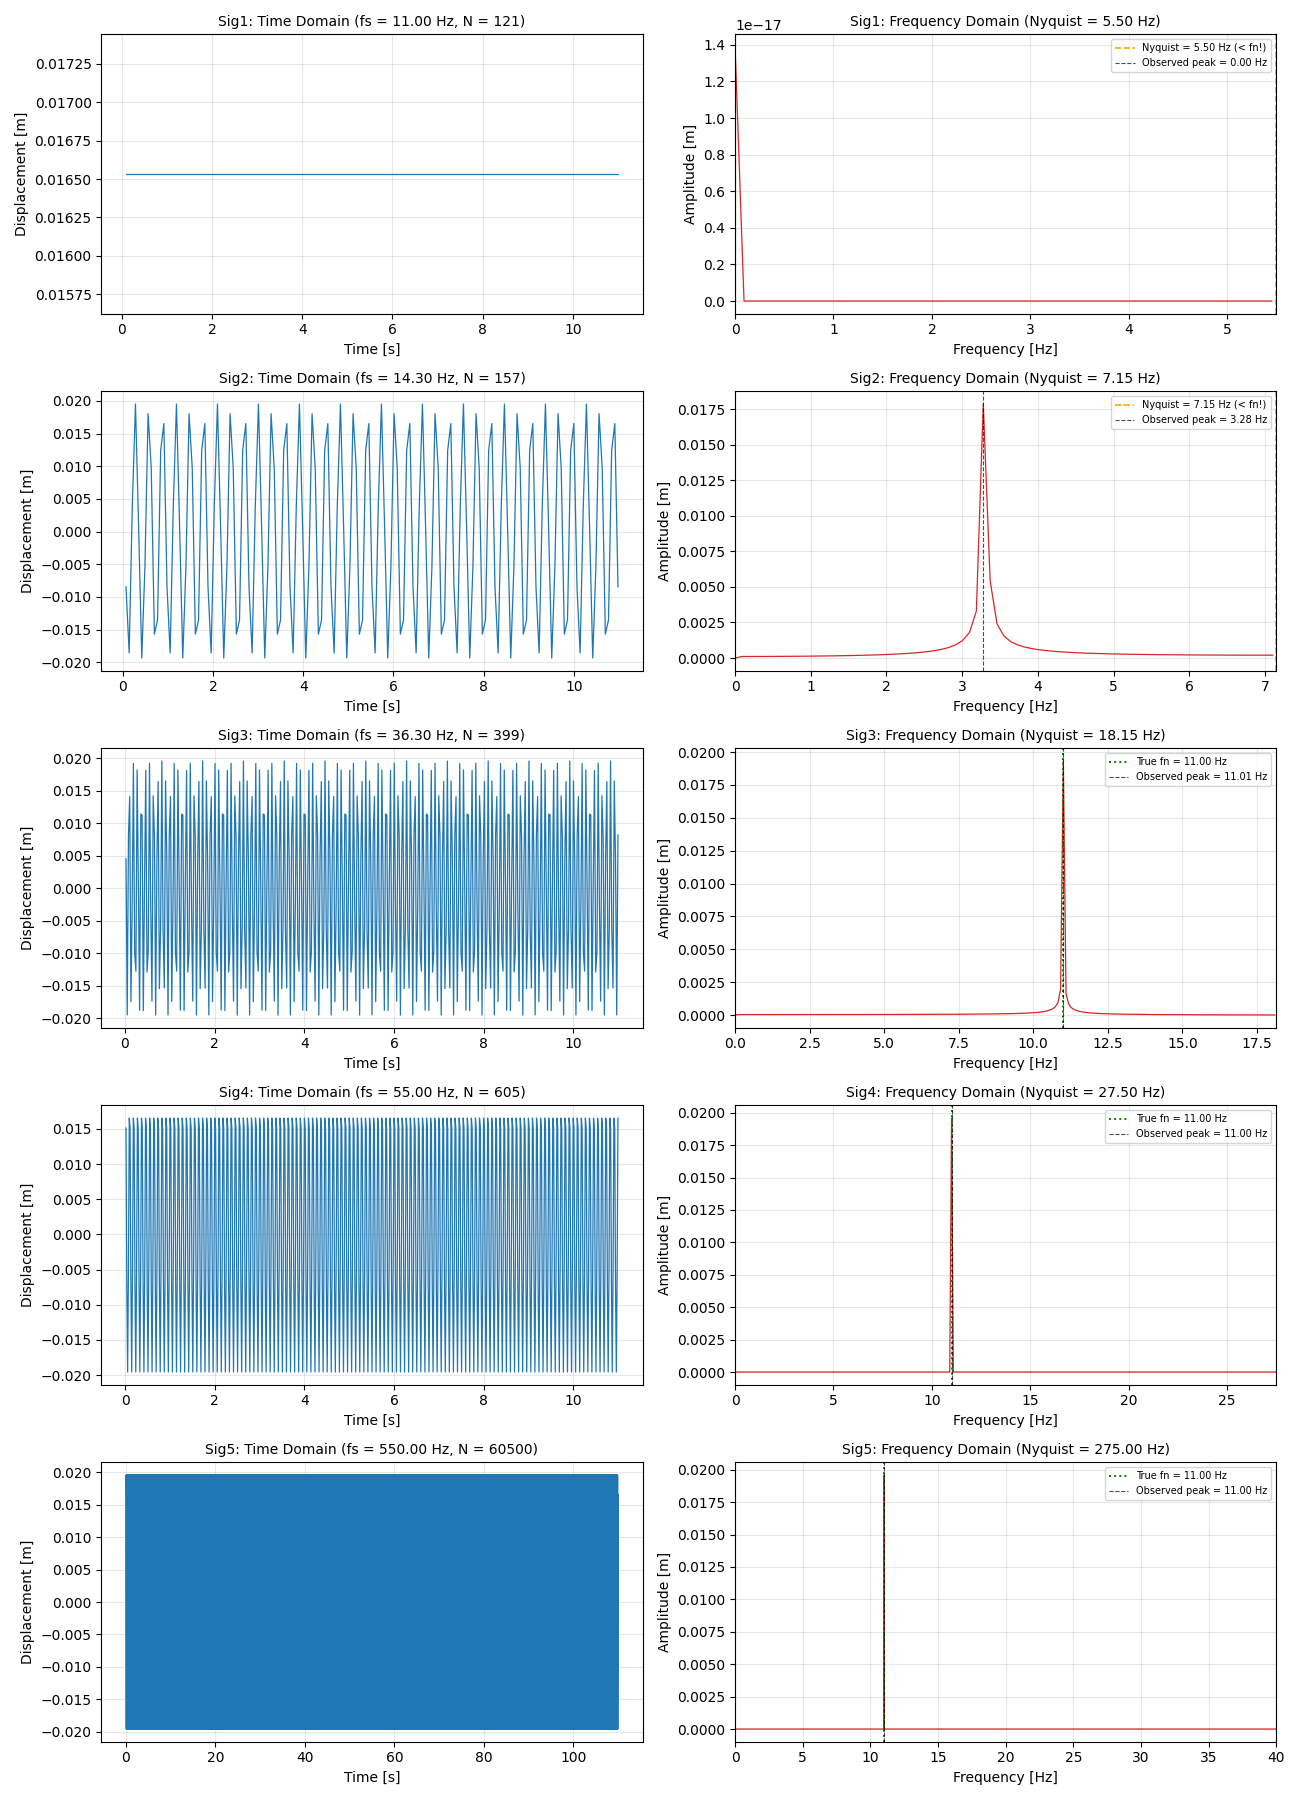

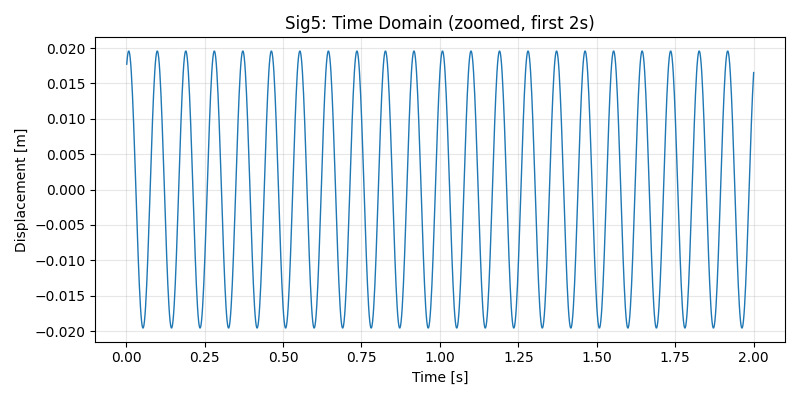

In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
# pip install ipympl
# %matplotlib widget

plt.close('all')
#System Properties
m = 10.60 #kg
k = 50635.02  #N/m
zeta = 0.00 

#Initial Conditions 
x0 = 0.02 #m
xdot_0 = 0.73 #m/s 

wn = np.sqrt(k/m) #rad/s
fn = wn / (2*np.pi) #Hz

print(f"m = {m} kg")
print(f"k = {k} N/m")
print(f"zeta = {zeta}")
print(f"x0 = {x0} m")
print(f"xdot_0 = {xdot_0} m/s")

data_folder = r"stud186"
%matplotlib widget
files = ['Sig1', 'Sig2', 'Sig3', 'Sig4', 'Sig5']

fig, axes = plt.subplots(5, 2, figsize=(13, 18))
results = {}

for i, f in enumerate(files):
    data = np.loadtxt(fr'{data_folder}\{f}.txt')
    t, x = data[:, 0], data[:, 1]
    dt = np.mean(np.diff(t))
    fs = 1 / dt
    N = len(t)
    nyq = fs / 2
    duration = t[-1] - t[0]
    delta_f = 1 / duration          # Rayleigh's criterion

    # Time domain
    ax_t = axes[i, 0]
    ax_t.plot(t, x, lw=0.9, color='tab:blue')
    ax_t.set_title(f'{f}: Time Domain (fs = {fs:.2f} Hz, N = {N})', fontsize=10)
    ax_t.set_xlabel('Time [s]')
    ax_t.set_ylabel('Displacement [m]')
    ax_t.grid(alpha=0.3)

    # Frequency domain
    X = np.fft.rfft(x - np.mean(x))
    freqs = np.fft.rfftfreq(N, d=dt)
    amp = (2 / N) * np.abs(X)

    ax_f = axes[i, 1]
    ax_f.plot(freqs, amp, lw=0.9, color='tab:red')
    ax_f.set_title(f'{f}: Frequency Domain (Nyquist = {nyq:.2f} Hz)', fontsize=10)
    ax_f.set_xlabel('Frequency [Hz]')
    ax_f.set_ylabel('Amplitude [m]')
    ax_f.set_xlim(0, min(nyq, 40))
    ax_f.grid(alpha=0.3)

    if fn <= nyq:
        ax_f.axvline(fn, color='green', ls=':', lw=1.4, label=f'True fn = {fn:.2f} Hz')
    else:
        ax_f.axvline(nyq, color='orange', ls='--', lw=1.2, label=f'Nyquist = {nyq:.2f} Hz (< fn!)')

    peak_idx = np.argmax(amp)
    peak_f = freqs[peak_idx]
    ax_f.axvline(peak_f, color='k', ls='--', lw=0.8, alpha=0.7, label=f'Observed peak = {peak_f:.2f} Hz')
    ax_f.legend(fontsize=7, loc='upper right')

    results[f] = dict(fs=fs, nyq=nyq, peak_f=peak_f, N=N, duration=duration, delta_f=delta_f)

# Print full summary table, including Rayleigh resolution
print(f"{'Signal':<8}{'fs (Hz)':>10}{'Nyquist':>10}{'Duration(s)':>13}{'Delta_f (Hz)':>14}{'Peak (Hz)':>12}")
for f, r in results.items():
    print(f"{f:<8}{r['fs']:>10.2f}{r['nyq']:>10.2f}{r['duration']:>13.2f}{r['delta_f']:>14.5f}{r['peak_f']:>12.4f}")

print(f"\nTrue natural frequency (from m, k): fn = {fn:.4f} Hz")

plt.tight_layout()
# plt.savefig('additional_signals_full.png', dpi=140)
plt.show()
# Zoomed view of Sig5 (first 2 seconds only)
data = np.loadtxt(fr'{data_folder}\Sig5.txt')
t, x = data[:, 0], data[:, 1]
mask = t <= 2

plt.figure(figsize=(8, 4))
plt.plot(t[mask], x[mask], lw=1, color='tab:blue')
plt.title('Sig5: Time Domain (zoomed, first 2s)')
plt.xlabel('Time [s]')
plt.ylabel('Displacement [m]')
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('sig5_zoomed.png', dpi=140)
plt.show()